# Routine to calculate vertical PDF of cloud top heigh from ZM convection
## Intended to examine impact of ZM KE parcel changes

In [10]:
import numpy as np
import matplotlib.pyplot as mp
import xarray as xr
import pandas as pd
import glob
import seaborn as sbn

from distributed import Client, LocalCluster
from ncar_jobqueue import NCARCluster

print(xr.__version__)

2024.10.0


In [7]:
# DASK

cluster = NCARCluster(project='P93300642',interface='ext', job_extra_directives=[],walltime ='12:00:00')
cluster
cluster.scale(jobs=32)
client = Client(cluster)
client

/glade/work/rneale/python/miniconda3/envs/neale_vproc/lib/python3.10/site-packages/dask_jobqueue/core.py:266: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/glade/work/rneale/python/miniconda3/envs/neale_vproc/lib/python3.10/site-packages/dask_jobqueue/core.py:285: FutureWarning: env_extra has been renamed to job_script_prologue. You are still using it (even if only set to []; please also check config files). If you did not set job_script_prologue yet, env_extra will be respected for now, but it will be removed in a future release. If you already set job_script_prologue, env_extra is ignored and you can remove it.
  warnings.warn(warn, Future

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/proxy/42399/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/proxy/42399/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.115:41473,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/proxy/42399/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [8]:
# Read files #

cases = ['f.cam6_3_161.FLTHIST_ne30.ke.000b_hf',
         'f.cam6_3_161.FLTHIST_ne30.ke.001_hf']

cnames = ['CAM7','CAM7+Convection-KE']


dir_in = ['s','s'] # s-scracth, c-campaign


lat_bounds = slice(30, 50)  # Latitude range
lon_bounds = slice(95, 135)  # Longitude range
time_range = slice("2010-08-01", "2010-08-31")  # Time range

#lat_bounds = slice(0, 10)  # Latitude range
#lon_bounds = slice(90, 120)  # Longitude range
#time_range = slice("2010-01-01", "2010-01-31")  # Time range


season0 = 'DJF'
vpscale = 86400.*1000.

#vname = 'PCONVT' ; vscale = 0.01 ; vunits = 'Pressure of Convective Tops' ; ylims = [1000.,50.] ; xlims = [1000.,50.] ; bwidth=20
vname = 'FLUT' ; vscale = 1. ; vunits = 'Outgoing Long-wave Radiation (W/m^2)' ; ylims = [1000.,50.] ; xlims = [300.,100.] ; bwidth=5

fdir_c = '/glade/campaign/cgd/amp/amwg/runs/'
fdir_s = '/glade/derecho/scratch/rneale/'





CASE =  f.cam6_3_161.FLTHIST_ne30.ke.000b_hf
/glade/derecho/scratch/rneale/archive/f.cam6_3_161.FLTHIST_ne30.ke.000b_hf/atm/hist/f.cam6_3_161.FLTHIST_ne30.ke.000b_hf*h3i*2010*nc
[      nan       nan       nan       nan       nan       nan 232.9672
       nan       nan       nan       nan       nan       nan       nan
 213.16414 174.80678 188.46056       nan       nan       nan       nan
       nan       nan       nan 232.8251  243.75519 253.15948 256.8714
       nan       nan       nan       nan       nan       nan       nan
       nan       nan       nan       nan 209.04263       nan       nan
       nan       nan       nan       nan 259.84744 220.20274 174.40033
 178.00226       nan       nan       nan       nan       nan       nan
 195.3667  199.6034  205.33432 225.05058 238.7558  253.35153       nan
       nan       nan       nan       nan       nan       nan       nan
       nan       nan 201.4103        nan       nan       nan       nan
       nan       nan       nan 235.3716  1

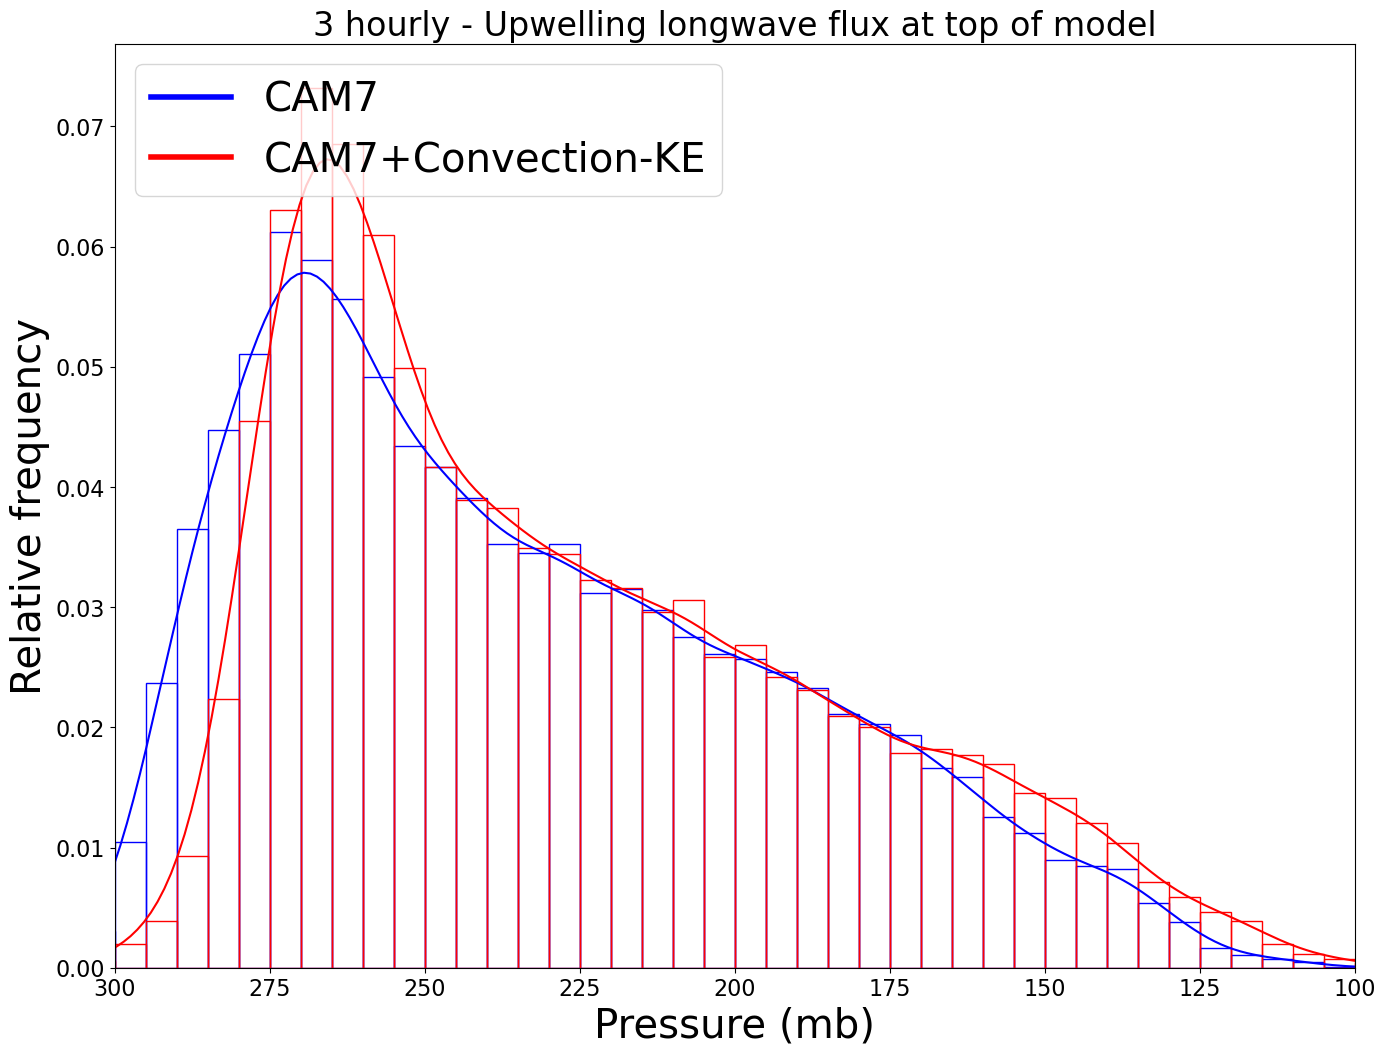

In [9]:
# PLOT HISTOGRAM #

plt1, ax1 = mp.subplots(1,1,figsize=(16, 12)) # Ave plot of all cases
#sbn.color_palette("colorblind")
#colors = ['olive','coral','purple']
colors = ['blue','red','purple']

for ic,case in enumerate(cases):

    
    print()
    print('CASE = ',case)
    
    if ic > 1:
        ffile0 = fdir_s+case+'/run/'+case
    else:
        ffile0 = fdir_s+'archive/'+cases[ic]+'/atm/hist/'+case
    
    
    ffile = ffile0+'*h3i*2010*nc'
    print(ffile)
    flist  = sorted(glob.glob(ffile))
    fhist  =  xr.open_mfdataset(flist,parallel=True)  
    fhist  = fhist.sel(lat=lat_bounds, lon=lon_bounds, time=time_range)


    
    fvar = fhist[vname]
    vlong =  fvar.attrs['long_name']    
    fvar = vscale*fvar

    fprecc = fhist['PRECC']
    fprecc = vpscale*fprecc
    
    # Mask
    fvar = fvar.where(fprecc > 1.)
    
    # 1d-ize
    pvar_1d = fvar.values.ravel()
    print(pvar_1d[0:100])
        
    # PDF
    
    sbn.histplot(pvar_1d, binwidth=bwidth, binrange=(40, 1000),color=colors[ic],linewidth=1,multiple="layer",kde=True, fill=False,stat="probability", ) 

    del pvar_1d

leg = ax1.legend(cnames,loc='upper left',fontsize=29)

#ylims = [0.,5000]

ax1.set_xlim(xlims)
#ax1.set_ylim(ylims)
#plt1.gca().invert_yaxis()
ax1.set_title('3 hourly - '+vlong,fontsize=24)
ax1.set_ylabel('Relative frequency',fontsize=29) 
ax1.set_xlabel('Pressure (mb)',fontsize=29)
ax1.tick_params(axis='x', labelsize=16)
ax1.tick_params(axis='y', labelsize=16)
#ax1.vlines(0.,ylims[0] ,ylims[1], color='black',linestyle="dashed",lw=1)

for line in leg.get_lines():
    line.set_linewidth(4.0)

plt1.savefig('pdf_vres_'+vname+'_Jul.png', dpi=100, bbox_inches='tight') 



NameError: name 'pdf_data_proc' is not defined

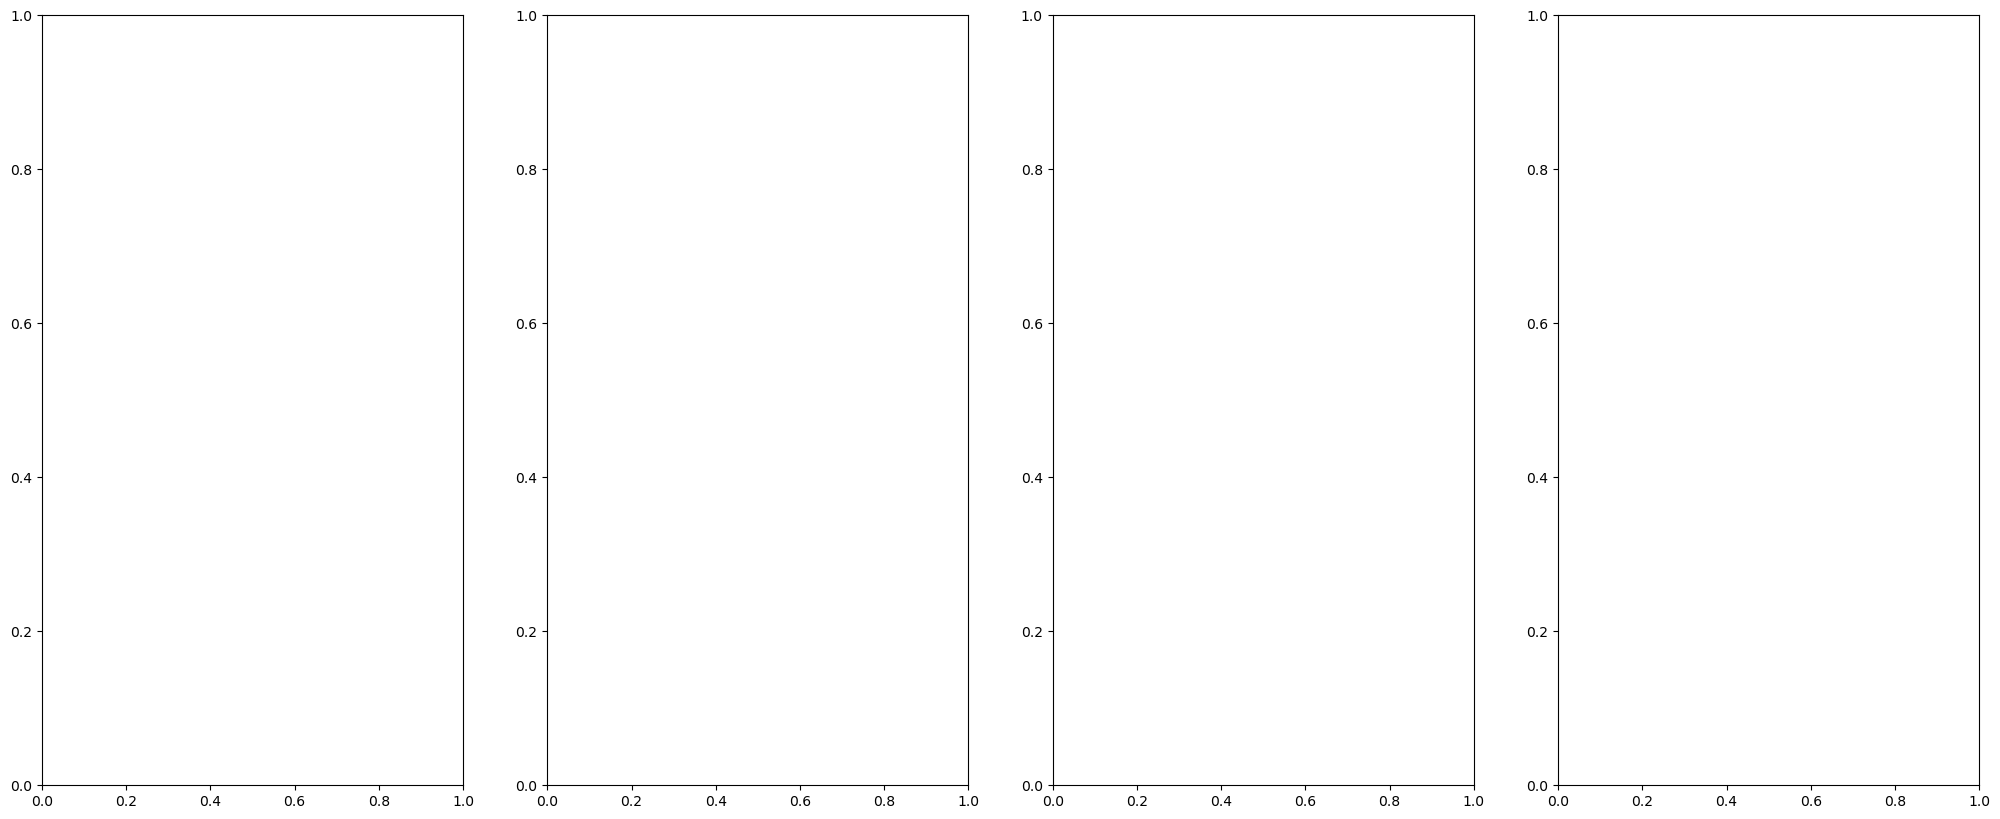

In [41]:
### 2D histogram ###

plt2, ax2 = mp.subplots(1,4,figsize=(25, 10)) # Ave plot of all cases

colors = ['black','skyblue','olive','coral']

for ic,case in enumerate(cases):

    fplot,vlong = pdf_data_proc(case,fdir0,vname,vscale) # Main variable
    fplotc,vlongc = pdf_data_proc(case,fdir0,vnamec,vscalec) # Always grab CONVECTIVE VARIABLE.
   
    

    ax2[ic].scatter(fplotc, fplot,color=colors[ic],alpha=0.1,marker='.',s=1)
    
#    ax2[ic].hist2d(fplotc, fplot, bins=(50, 50),range=([-50,10],[-20,50]))
    
    ax2[ic].vlines(0.,-60, 80, color='black',linestyle="dashed",lw=1)
    ax2[ic].hlines(0.,-60, 10, color='black',linestyle="dashed",lw=1)
    
    ax2[ic].set_title(cnames[ic],fontsize=24)
    ax2[ic].set_ylabel(vlong,fontsize=20) 
    ax2[ic].set_xlabel(vlongc,fontsize=15)
    ax2[ic].tick_params(axis='x', labelsize=16)
    ax2[ic].tick_params(axis='y', labelsize=16)
    
plt2.savefig('pdf_vres_scatter.png', dpi=100, bbox_inches='tight') 